In [2]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#load the data
df=pd.read_csv('netflix_titles.csv')

In [6]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


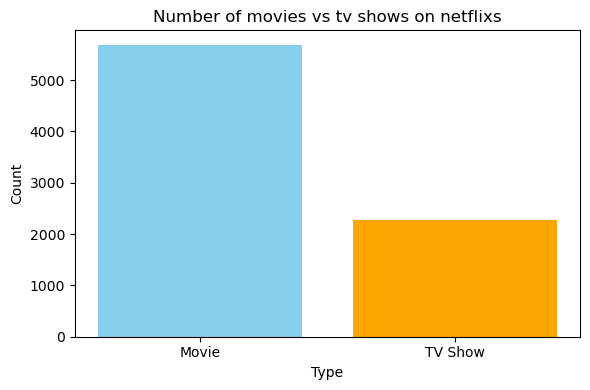

In [11]:
#clean the data
df=df.dropna(subset=['type','release_year','rating','country','duration'])

type_counts=df['type'].value_counts()
type_counts
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=["skyblue",'orange'])
plt.title("Number of movies vs tv shows on netflixs")
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_tvshows')
plt.show()
            

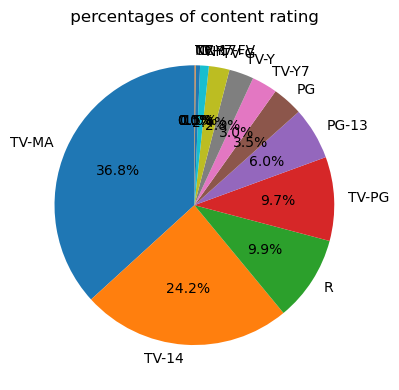

In [12]:
rating_counts=df['rating'].value_counts()

plt.figure(figsize=(6,4))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%',startangle=90)
plt.title(" percentages of content rating ")

plt.tight_layout()
plt.savefig('content_rating_pie.png')
plt.show()

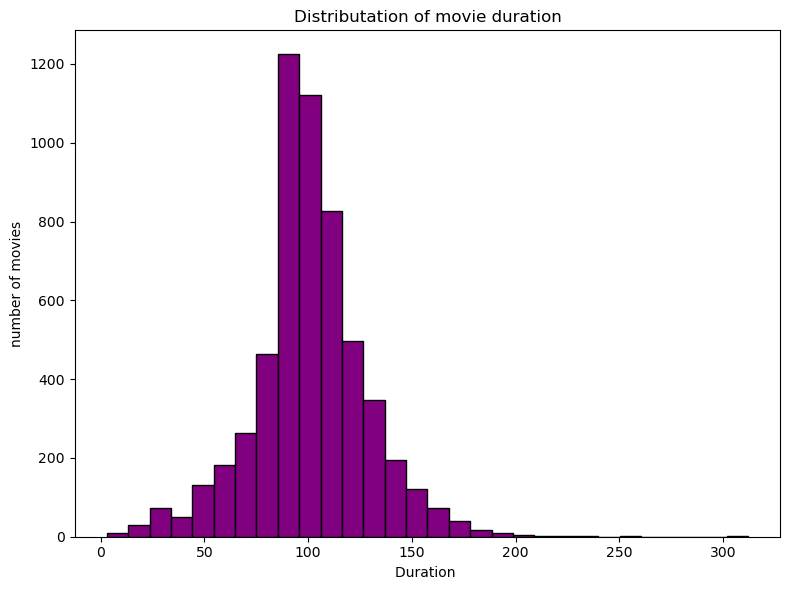

In [16]:
#
movie_df=df[df['type']=='Movie'].copy()
movie_df['duration_int']= movie_df['duration'].str.replace('min','').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30, color="purple",edgecolor="black")
plt.title("Distributation of movie duration")
plt.xlabel('Duration ')
plt.ylabel('number of movies')
plt.tight_layout()
plt.savefig('movies_duration_histogram.png')
plt.show()
         

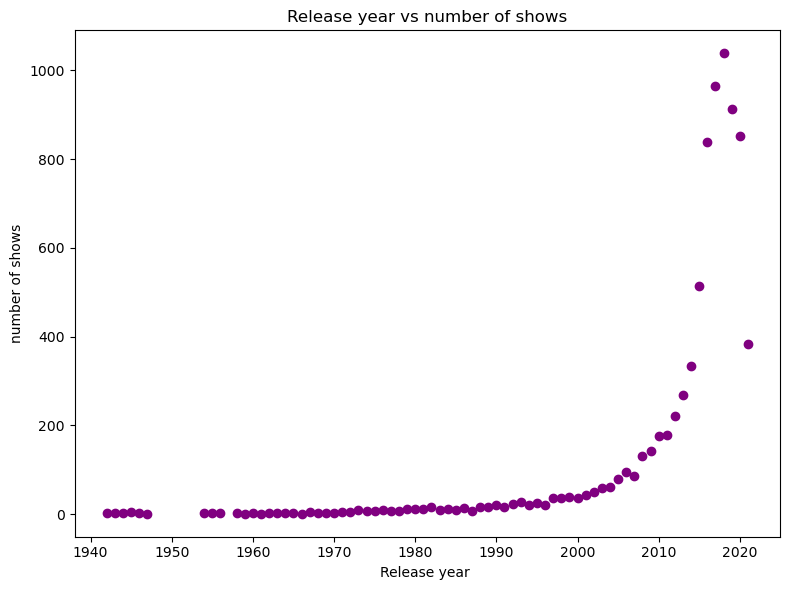

In [19]:
release_counts=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,6))
plt.scatter(release_counts.index,release_counts.values, color="purple")
plt.title("Release year vs number of shows")
plt.xlabel('Release year ')
plt.ylabel('number of shows')
plt.tight_layout()
plt.savefig('release_year.png')
plt.show()
         

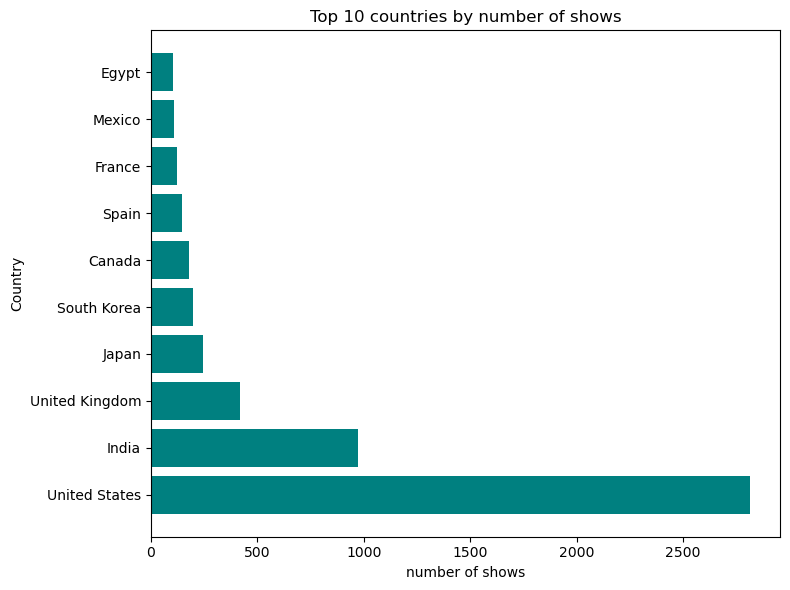

In [20]:
country_counts=df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title("Top 10 countries by number of shows")
plt.xlabel('number of shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()

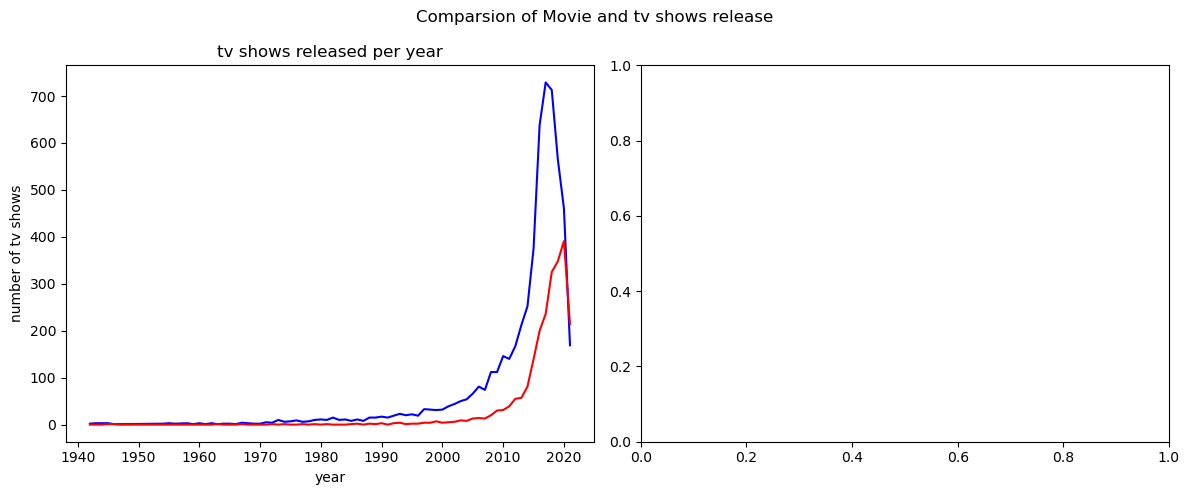

In [25]:
content_by_year=df.groupby(['release_year','type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize=(12,5))
#first subplots:movies
ax[0].plot(content_by_year.index,content_by_year['Movie'],color ='blue')
ax[0].set_title("movies released per year")
ax[0].set_xlabel("year")
ax[0].set_ylabel("number of movies")

#second subplot:tv shows
ax[0].plot(content_by_year.index,content_by_year['TV Show'],color ='red')
ax[0].set_title("tv shows released per year")
ax[0].set_xlabel("year")
ax[0].set_ylabel("number of tv shows")

fig.suptitle('Comparsion of Movie and tv shows release')
plt.tight_layout()
plt.savefig("movies_tv_shows_comparsion.png")
plt.show()
                 